In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [4]:
df = df.drop_duplicates()

df = df.drop(columns=[
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
    'Common_Keywords'
], errors='ignore')

df = df.dropna()

In [5]:
le = LabelEncoder()

df['Subscription_Tier'] = le.fit_transform(df['Subscription_Tier'])

In [6]:
X = df.drop(columns=['Revenue_Generated'])

y = df['Revenue_Generated']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
8,Bundle_Price,0.130451
0,Budget,0.130290
1,Clicks,0.128780
2,Conversions,0.123893
3,ROI,0.121515
7,Units_Sold,0.116932
6,Discount_Level,0.101262
5,Subscription_Length,0.088470
9,Customer_Satisfaction_Post_Refund,0.033022
4,Subscription_Tier,0.025385


In [9]:
importance_df.to_csv(
    'RQ4_Feature_Importance.csv',
    index=False
)

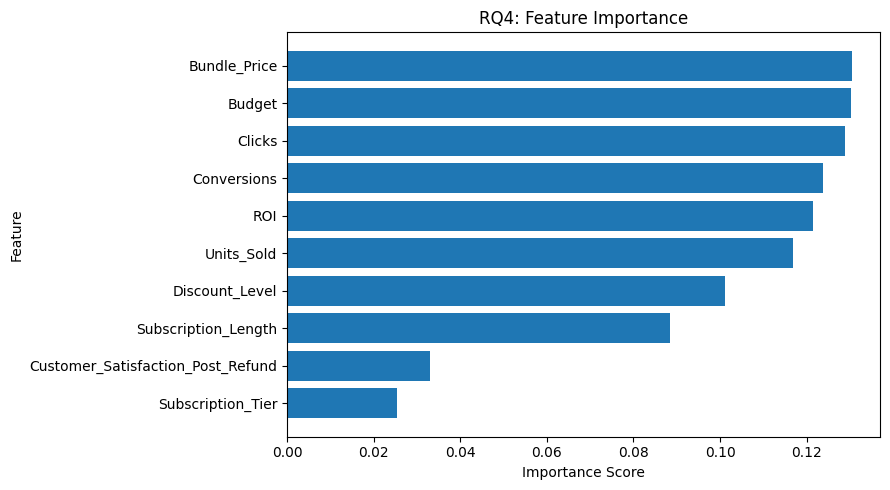

In [10]:
top_features = importance_df.head(10)

plt.figure(figsize=(9,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance Score')

plt.ylabel('Feature')

plt.title('RQ4: Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig('RQ4_Feature_Importance.pdf')

plt.show()

## Conclusion

Budget, conversions, ROI, and units sold were among the most influential variables affecting revenue prediction.